In [1]:
import matplotlib.pyplot as plt
import cv2
import os
import torch
import torchvision
from PIL import Image
import numpy as np
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from pathlib import Path

In [2]:
# Check if CUDA is available and set device accordingly
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

cuda


In [3]:
class ChessmanDataset(Dataset):
    # Custom dataset class for loading images and annotations in COCO format
    def __init__(self, image_dir, annotation_file, transforms=None):
        self.image_dir = image_dir
        self.coco = COCO(annotation_file)
        self.transforms = transforms
        self.image_ids = list(self.coco.imgs.keys())

    # Return the number of samples in the dataset
    def __len__(self):
        return len(self.image_ids)

    # Load image and corresponding annotations for a given index
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = os.path.join(self.image_dir, image_info['file_name'])
        
        # Load image
        image = Image.open(image_path).convert("RGB")
        
        # Load annotations
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annotation_ids)

        # Convert annotations to the format expected by Faster R-CNN
        boxes = []
        labels = []
        for obj in annotations:
            xmin, ymin, width, height = obj['bbox']
            xmax = xmin + width
            ymax = ymin + height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(obj['category_id'])

        # Convert lists to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        area = torch.as_tensor([obj['area'] for obj in annotations],    dtype=torch.float32)
        iscrowd = torch.as_tensor([obj.get('iscrowd', 0) for obj in annotations], dtype=torch.int64)

        # Create target dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
        
        # Apply transformations to the image (if any)
        if self.transforms:
            image = self.transforms(image)

        # Handle cases where there are no annotations (i.e., no bounding boxes)
        if np.isnan((target['boxes']).numpy()).any() or target['boxes'].shape == torch.Size([0]):
            target['boxes'] = torch.zeros((0,4),dtype=torch.float32)
        
        return image, target

In [4]:
# Set paths
project_dir = Path.cwd().parent
print(project_dir)

c:\Users\feran\Projects\chessify


In [5]:
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

# Convert PIL images to tensors
def get_transform():
    return ToTensor()

# Load training dataset
train_dataset = ChessmanDataset(image_dir=project_dir / 'data' / 'ChessmanDetection.v1-base-dataset-21-05-26.coco' / 'train', 
                                     annotation_file=project_dir / 'data' / 'ChessmanDetection.v1-base-dataset-21-05-26.coco' / 'train' / '_annotations.coco.json', 
                                     transforms=get_transform())

# Load validation dataset
val_dataset = ChessmanDataset(image_dir=project_dir / 'data' / 'ChessmanDetection.v1-base-dataset-21-05-26.coco' / 'valid', 
                                   annotation_file=project_dir / 'data' / 'ChessmanDetection.v1-base-dataset-21-05-26.coco' / 'valid' / '_annotations.coco.json', 
                                   transforms=get_transform())

# Create data loaders for training and validation datasets
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


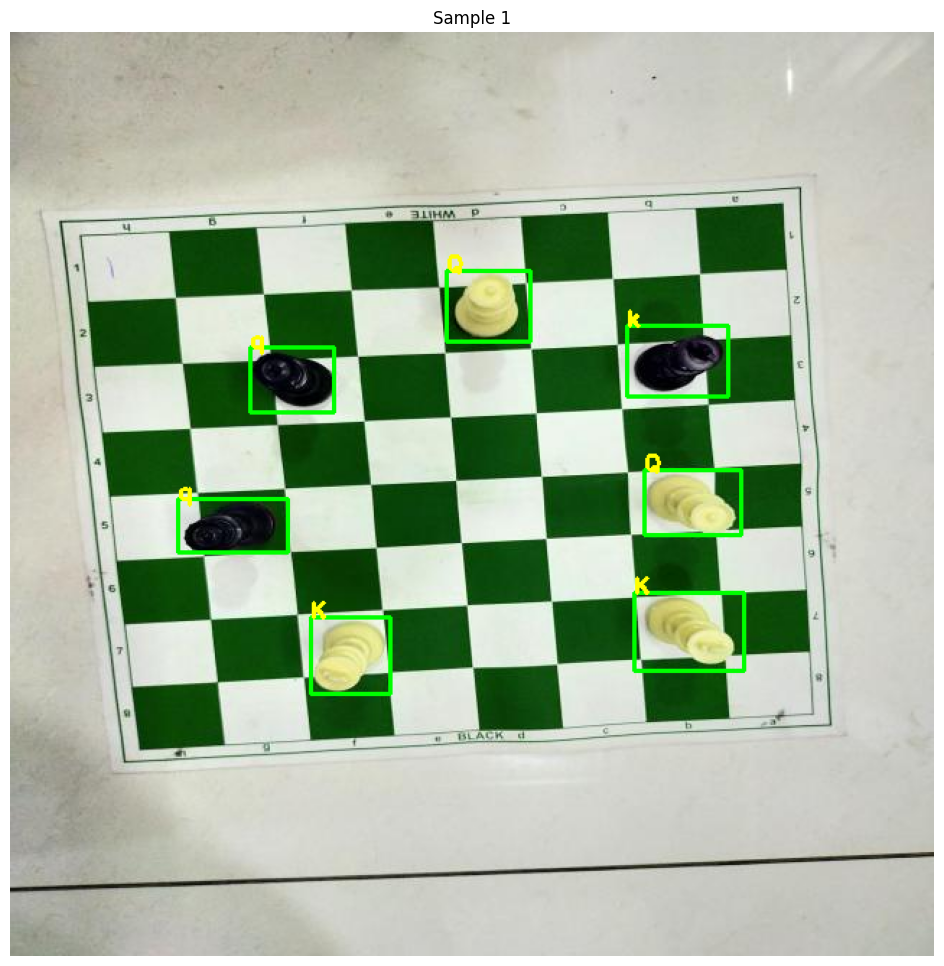

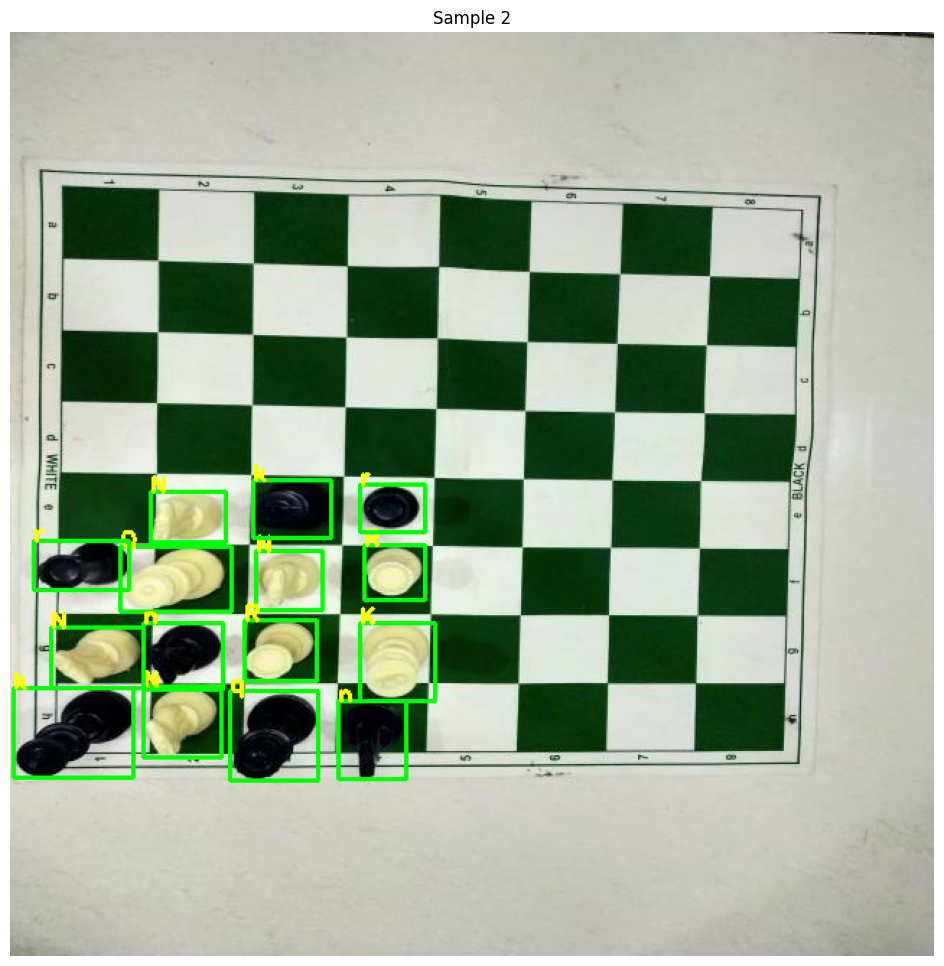

In [8]:
# Visualize one batch of images with bounding boxes and labels
images, targets = next(iter(train_loader))

label_list = ["", "B", "K", "N", "P", "Q", "R", "b", "k", "n", "p", "q", "r", ""]

for i in range(len(images)):
    # CxHxW --> HxWxC
    image = images[i].permute(1, 2, 0).numpy()   
    # Rescale
    image = (image * 255).astype(np.uint8)   
    # Convert RGB to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    
    # Draw bounding boxes and labels on the image
    boxes = targets[i]['boxes']
    labels = targets[i]['labels']

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = map(int, box.tolist())
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"{label_list[label.item()]}", (x1, y1),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    # Show image with bounding boxes using matplotlib
    plt.figure(figsize=(16, 12))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Sample {i + 1}")
    plt.show()

In [9]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor, FasterRCNN_ResNet50_FPN_V2_Weights

# Load pre-trained Faster R-CNN model with ResNet50 backbone and FPN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)

# Number of classes in the dataset (note: +1 because of the background class)
num_classes = len(train_dataset.coco.getCatIds()) + 1  

# Number of input features for classifier head
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to the GPU for faster training
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

In [10]:
# Get trainable parameters
params = [p for p in model.parameters() if p.requires_grad]

# Define the optimizer for training the model (Stochastic Gradient Descent with momentum and weight decay)
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)

# Define the learning rate scheduler to decrease the learning rate by a factor of 10 every 3 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [11]:
def get_validation_losses(model, data_loader, device):
    """Function for computing validation losses"""
    # Torchvision detection models compute losses only in train mode, so we switch to train mode temporarily
    model.train()
    
    # Dictionary to accumulate loss sums for each loss component
    val_loss_sums = {
        'loss': 0.0,
        'loss_classifier': 0.0,
        'loss_box_reg': 0.0,
        'loss_objectness': 0.0,
        'loss_rpn_box_reg': 0.0
    }
    # Number of batches in the validation data loader for averaging losses later
    num_batches = len(data_loader)
    
    # Turn off gradient tracking to prevent weight leakage and save memory during validation
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in t.items()} for t in targets]
            
            # Forward pass to get losses
            loss_dict = model(images, targets)
            # Convert tensors to scalars and sum up losses to get total loss for the batch
            loss_dict = {k: v.item() for k, v in loss_dict.items()}
            total_loss = loss_dict['loss'] if 'loss' in loss_dict else sum(loss_dict.values())

            # Accumulate each loss component and the total loss for the epoch    
            val_loss_sums['loss'] += total_loss
            for k, v in loss_dict.items():
                if k in val_loss_sums:
                    val_loss_sums[k] += v
            
            # Explicitly delete variables that hold references to the computation graph to free up VRAM
            del images, targets
            
    # Prevent leaking training mode state outside this function
    model.eval()
    # Return average losses for the epoch formatted as strings with 3 decimal places
    return {k: v / num_batches for k, v in val_loss_sums.items()}

In [12]:
from engine import train_one_epoch, evaluate
import pickle

# Set the number of epochs for training and initialize history list to store metrics
num_epochs = 20
history = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    # Train for one epoch and compute training losses
    metric_logger = train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=25)
    epoch_train_losses = {k: meter.global_avg for k, meter in metric_logger.meters.items() if k != 'lr'}
    
    # Compute validation losses
    epoch_val_losses = get_validation_losses(model, val_loader, device)
    
    # Compute validation detection metrics using COCO evaluation API
    coco_evaluator = evaluate(model, val_loader, device=device)

    # Extract relevant metrics from coco_evaluator
    epoch_detection_metrics = {
        'mAP': coco_evaluator.coco_eval["bbox"].stats[0],
        'mAP_50': coco_evaluator.coco_eval["bbox"].stats[1],
        'mAP_75': coco_evaluator.coco_eval["bbox"].stats[2],
        'mAP_small': coco_evaluator.coco_eval["bbox"].stats[3],
        'mAP_medium': coco_evaluator.coco_eval["bbox"].stats[4],
        'mAP_large': coco_evaluator.coco_eval["bbox"].stats[5],
        'mAR_1': coco_evaluator.coco_eval["bbox"].stats[6],
        'mAR_10': coco_evaluator.coco_eval["bbox"].stats[7],
        'mAR_100': coco_evaluator.coco_eval["bbox"].stats[8],
        'mAR_small': coco_evaluator.coco_eval["bbox"].stats[9],
        'mAR_medium': coco_evaluator.coco_eval["bbox"].stats[10],
        'mAR_large': coco_evaluator.coco_eval["bbox"].stats[11]
    }
    
    # Save epoch metrics to history for later analysis and visualization
    history.append({
        'epoch': epoch + 1,
        'train_losses': epoch_train_losses,
        'val_losses': epoch_val_losses,
        'detection_metrics': epoch_detection_metrics
    })

    # Print training and validation losses for the current epoch
    print(f"Epoch {epoch + 1}: train loss = {epoch_train_losses['loss']:.4f}, val loss = {epoch_val_losses['loss']:.4f}")
    
    # Step the learning rate scheduler to update the learning rate based on the defined schedule
    scheduler.step()
    
    # Save model checkpoint for the current epoch
    torch.save(model.state_dict(), project_dir / 'models' / f'model_epoch_{epoch + 1}.pth')

# Save training history to a file for later analysis and visualization
with open(project_dir / 'training_history.pkl', 'wb') as f:
    pickle.dump(history, f)


Epoch 1/20


c:\Users\feran\Projects\chessify\training\engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [   0/2635]  eta: 1:15:22  lr: 0.000010  loss: 3.8503 (3.8503)  loss_classifier: 2.6727 (2.6727)  loss_box_reg: 0.3913 (0.3913)  loss_objectness: 0.7314 (0.7314)  loss_rpn_box_reg: 0.0549 (0.0549)  time: 1.7162  data: 0.0153  max mem: 2600
Epoch: [0]  [  25/2635]  eta: 0:16:12  lr: 0.000135  loss: 2.7177 (2.9975)  loss_classifier: 2.1757 (2.2939)  loss_box_reg: 0.4307 (0.4131)  loss_objectness: 0.1332 (0.2571)  loss_rpn_box_reg: 0.0265 (0.0334)  time: 0.3179  data: 0.0121  max mem: 2801
Epoch: [0]  [  50/2635]  eta: 0:14:56  lr: 0.000260  loss: 1.5161 (2.3645)  loss_classifier: 0.8564 (1.6534)  loss_box_reg: 0.5070 (0.4987)  loss_objectness: 0.0485 (0.1797)  loss_rpn_box_reg: 0.0278 (0.0327)  time: 0.3204  data: 0.0122  max mem: 2801
Epoch: [0]  [  75/2635]  eta: 0:14:26  lr: 0.000385  loss: 1.3154 (2.0233)  loss_classifier: 0.6674 (1.3331)  loss_box_reg: 0.5484 (0.5233)  loss_objectness: 0.0438 (0.1356)  loss_rpn_box_reg: 0.0177 (0.0313)  time: 0.3205  data: 0.0119  max me

In [15]:
for epoch_data in history:
    epoch = epoch_data['epoch']
    train_loss = epoch_data['train_losses']['loss']
    val_loss = epoch_data['val_losses']['loss']
    print(f"Epoch {epoch}: train loss = {train_loss:.4f}, val loss = {val_loss:.4f}")

Epoch 1: train loss = 0.6206, val loss = 0.4951
Epoch 2: train loss = 0.3570, val loss = 0.4152
Epoch 3: train loss = 0.3039, val loss = 0.4032
Epoch 4: train loss = 0.2314, val loss = 0.3425
Epoch 5: train loss = 0.2116, val loss = 0.3376
Epoch 6: train loss = 0.2012, val loss = 0.3377
Epoch 7: train loss = 0.1902, val loss = 0.3336
Epoch 8: train loss = 0.1894, val loss = 0.3339
Epoch 9: train loss = 0.1878, val loss = 0.3340
Epoch 10: train loss = 0.1869, val loss = 0.3340
Epoch 11: train loss = 0.1863, val loss = 0.3335
Epoch 12: train loss = 0.1860, val loss = 0.3342
Epoch 13: train loss = 0.1865, val loss = 0.3340
Epoch 14: train loss = 0.1864, val loss = 0.3329
Epoch 15: train loss = 0.1866, val loss = 0.3321
Epoch 16: train loss = 0.1863, val loss = 0.3334
Epoch 17: train loss = 0.1865, val loss = 0.3340
Epoch 18: train loss = 0.1863, val loss = 0.3338
Epoch 19: train loss = 0.1861, val loss = 0.3331
Epoch 20: train loss = 0.1865, val loss = 0.3330


In [13]:
history

[{'epoch': 1,
  'train_losses': {'loss': 0.6206116067333963,
   'loss_classifier': 0.336679123970459,
   'loss_box_reg': 0.2517794484435183,
   'loss_objectness': 0.01440796989607258,
   'loss_rpn_box_reg': 0.017745065006831276},
  'val_losses': {'loss': 0.49507646594254856,
   'loss_classifier': 0.23396559564589037,
   'loss_box_reg': 0.2204134456845385,
   'loss_objectness': 0.014559128760532919,
   'loss_rpn_box_reg': 0.02613829585158676},
  'detection_metrics': {'mAP': np.float64(0.47666803390539914),
   'mAP_50': np.float64(0.7830335106768952),
   'mAP_75': np.float64(0.5400140540345599),
   'mAP_small': np.float64(0.3039515129597532),
   'mAP_medium': np.float64(0.4784924088802273),
   'mAP_large': np.float64(0.5528411378068513),
   'mAR_1': np.float64(0.22070174124234906),
   'mAR_10': np.float64(0.6076836707901083),
   'mAR_100': np.float64(0.6358125313883214),
   'mAR_small': np.float64(0.49601920052914505),
   'mAR_medium': np.float64(0.6350718556166709),
   'mAR_large': np.f

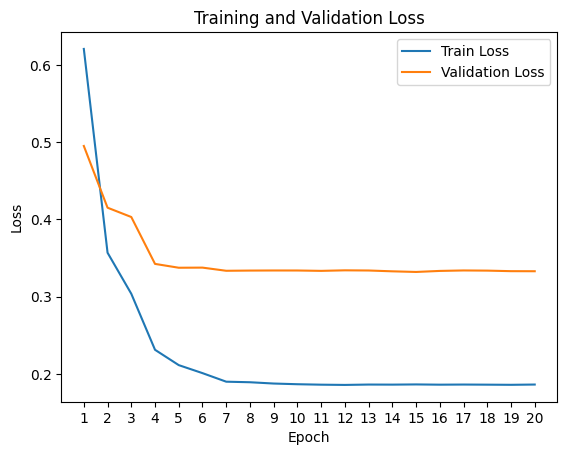

In [24]:
epochs = range(1, num_epochs + 1)
train_losses = [epoch_data['train_losses']['loss'] for epoch_data in history]
val_losses = [epoch_data['val_losses']['loss'] for epoch_data in history]
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xticks(range(1, num_epochs + 1))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='best')
plt.show()

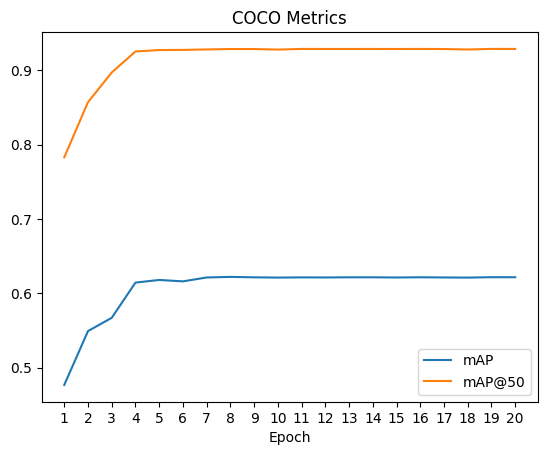

In [26]:
epochs = range(1, num_epochs + 1)
map_values = [epoch_data['detection_metrics']['mAP'] for epoch_data in history]
map_50_values = [epoch_data['detection_metrics']['mAP_50'] for epoch_data in history]
plt.plot(epochs, map_values, label='mAP')
plt.plot(epochs, map_50_values, label='mAP@50')
plt.xticks(range(1, num_epochs + 1))
plt.xlabel('Epoch')
plt.title('COCO Metrics')
plt.legend(loc='best')
plt.show()

In [49]:
# Load the same model architecture used for training, but without pre-trained weights
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=False, num_classes=num_classes)

# Load the trained model and set it to evaluation mode
model.load_state_dict(torch.load(project_dir / 'models' / 'model_epoch_15.pth'))
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

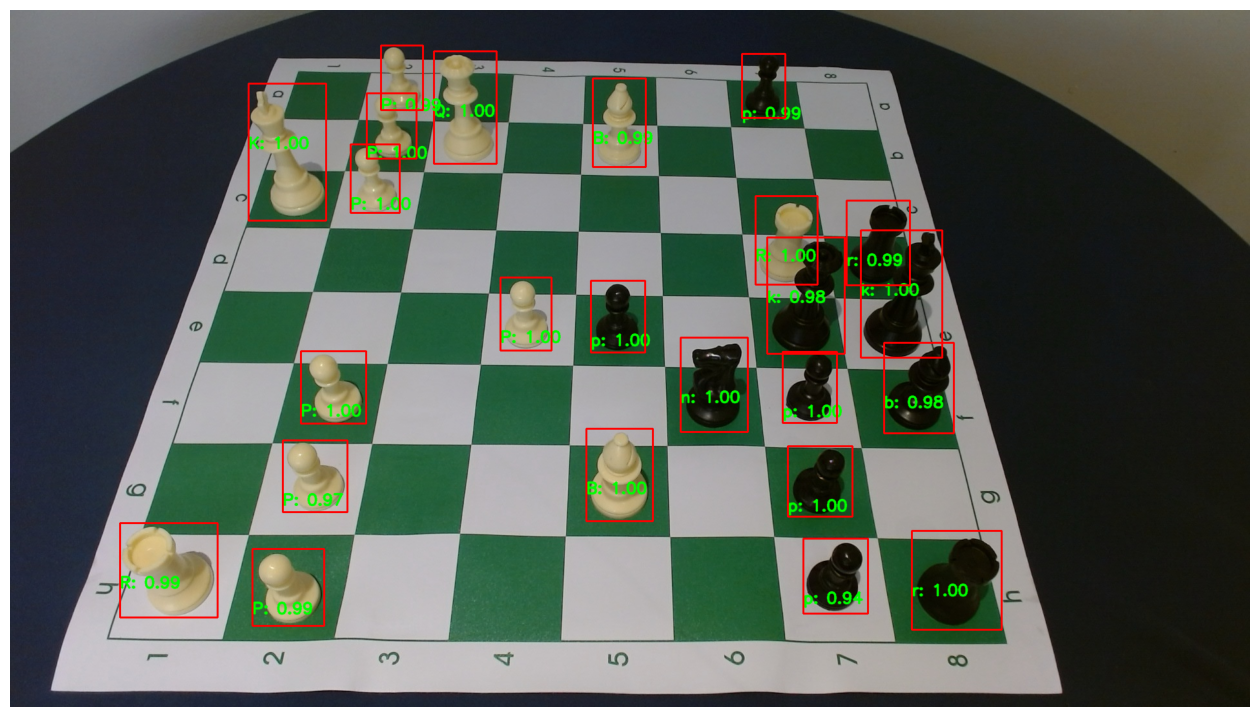

In [60]:
image_path = project_dir / "notebooks" / "game_opera_side" / "game_opera25.jpg"
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_pil = Image.fromarray(image_rgb)

transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
image_tensor = transform(image_pil).unsqueeze(0)

    # Inference
with torch.no_grad():
    predictions = model(image_tensor)

    # Detection data
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

threshold = 0.7
for i in range(len(boxes)):
    if scores[i] > threshold:
        box = boxes[i].cpu().numpy().astype(int)
        label = label_list[labels[i]]
        score = scores[i].item()

        text = f"{label}: {score:.2f}"
        cv2.putText(image_bgr, text, (box[0], box[1] + 100), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0, 255, 0), 2, cv2.LINE_AA)

        # Draw bounding box and label
        cv2.rectangle(image_bgr, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 2)

# Convert BGR --> RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Show image with labels and bounding boxes using matplotlib
plt.figure(figsize=(16, 12)) 
plt.imshow(image_rgb)
plt.axis('off')
plt.show()